# Task 3 — Real-Time Echocardiogram Video Analysis


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

DATA_DIR = "data"
OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

VIDEO_PATH = os.path.join(DATA_DIR, "echo_clip.mp4")

# Toggle this to True when running locally with a display attached.
LIVE_DISPLAY = False


## 1. Video Capture Setup

In [2]:
cap = cv2.VideoCapture(VIDEO_PATH)
assert cap.isOpened(), f"Could not open video at {VIDEO_PATH}"

fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print(f"Opened {VIDEO_PATH}")
print(f"FPS: {fps:.2f} | Frames: {frame_count} | Resolution: {width}x{height}")


Opened data/echo_clip.mp4
FPS: 50.00 | Frames: 173 | Resolution: 112x112


## 2. Per-Frame Enhancement Functions

In [3]:
def color_balance(img_bgr, gain=(1.0, 1.0, 1.0)):
    balanced = img_bgr.astype(np.float32)
    for c, g in enumerate(gain):
        balanced[:, :, c] *= g
    return np.clip(balanced, 0, 255).astype(np.uint8)

def log_transform(img, c=None):
    img_f = img.astype(np.float32)
    if c is None:
        c = 255 / np.log(1 + img_f.max() + 1e-6)
    return np.clip(c * np.log(1 + img_f), 0, 255).astype(np.uint8)

def gamma_transform(img, gamma=0.7, c=1.0):
    img_norm = img.astype(np.float32) / 255.0
    return np.clip(c * np.power(img_norm, gamma) * 255, 0, 255).astype(np.uint8)

def enhance_frame(frame_gray):
    """Full per-frame enhancement pipeline for one ultrasound frame."""
    # 1. Histogram equalization to fight murky low contrast
    eq = cv2.equalizeHist(frame_gray)

    # 2. Colored heatmap to highlight blood-flow / tissue-density intensity
    heat = cv2.applyColorMap(eq, cv2.COLORMAP_JET)

    # 3. Color balance adjustment (neutralize colormap cast)
    heat = color_balance(heat, gain=(1.05, 1.00, 0.95))

    # 4. Logarithmic transform - reveal dark heart-chamber detail
    heat = log_transform(heat)

    # 5. Power-law transform - suppress blinding white backscatter noise
    heat = gamma_transform(heat, gamma=0.7)

    return heat


## 3. Real-Time Video Processing Loop

In [4]:
cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

# Collect a handful of side-by-side frames for the saved notebook / screenshots,
# and (optionally) write a full side-by-side comparison video to output/.
sample_frames = []
out_writer = None
frame_idx = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY) if frame.ndim == 3 else frame
    raw_bgr = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

    enhanced = enhance_frame(gray)

    # Monitoring array: raw feed next to fully enhanced feed
    side_by_side = np.hstack([raw_bgr, enhanced])

    if LIVE_DISPLAY:
        # --- This branch is what you run locally with a display attached ---
        cv2.imshow("Raw (left) vs Enhanced (right)", side_by_side)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
    else:
        # --- Headless-safe path used to produce this saved notebook ---
        if out_writer is None:
            h, w = side_by_side.shape[:2]
            fourcc = cv2.VideoWriter_fourcc(*"mp4v")
            out_writer = cv2.VideoWriter(
                os.path.join(OUTPUT_DIR, "side_by_side_pipeline.mp4"),
                fourcc, fps if fps > 0 else 15, (w, h)
            )
        out_writer.write(side_by_side)

        if frame_idx % max(1, frame_count // 6) == 0 and len(sample_frames) < 6:
            sample_frames.append(cv2.cvtColor(side_by_side, cv2.COLOR_BGR2RGB))

    frame_idx += 1

cap.release()
if out_writer is not None:
    out_writer.release()
if LIVE_DISPLAY:
    cv2.destroyAllWindows()

print(f"Processed {frame_idx} frames.")


Processed 173 frames.


## 4. Monitoring Array — Raw vs Enhanced Screenshots

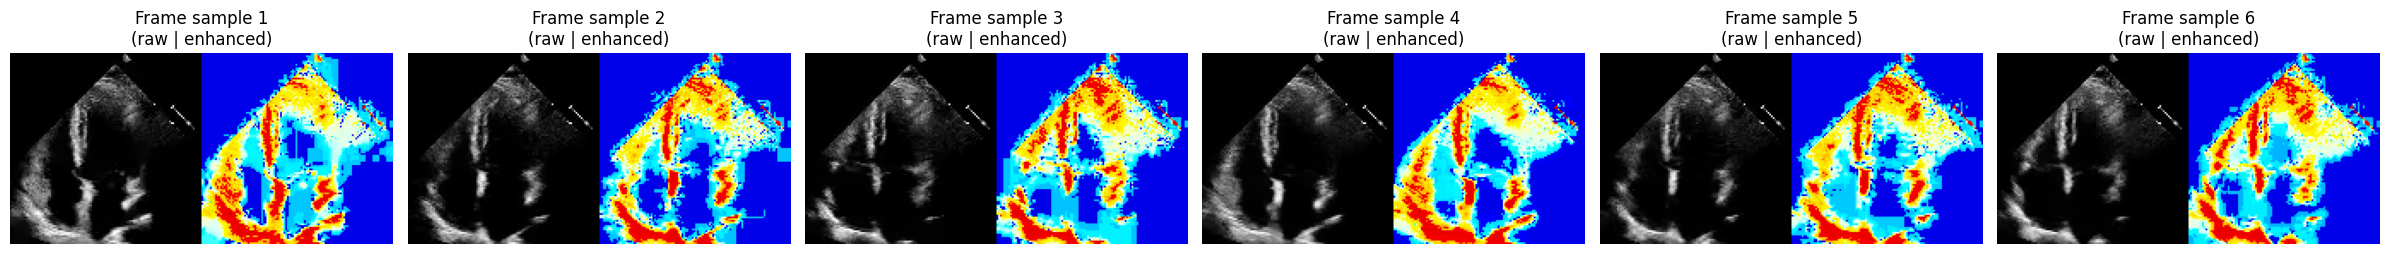

Saved side-by-side comparison video to: output/side_by_side_pipeline.mp4
Saved sample frame screenshots to: output/sample_pipeline_frames.png


In [5]:
n = len(sample_frames)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
if n == 1:
    axes = [axes]
for i, (ax, f) in enumerate(zip(axes, sample_frames)):
    ax.imshow(f)
    ax.set_title(f"Frame sample {i+1}\n(raw | enhanced)")
    ax.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "sample_pipeline_frames.png"), dpi=150)
plt.show()

print("Saved side-by-side comparison video to:",
      os.path.join(OUTPUT_DIR, "side_by_side_pipeline.mp4"))
print("Saved sample frame screenshots to:",
      os.path.join(OUTPUT_DIR, "sample_pipeline_frames.png"))


### Running the true live `cv2.imshow()` loop locally

1. Clone this repo and `cd` into `Task_3_Echo_Analysis/`.
2. `pip install -r ../requirements.txt`
3. Open `realtime_echo.ipynb` and set `LIVE_DISPLAY = True` in the setup cell.
4. Run all cells. A window titled **"Raw (left) vs Enhanced (right)"** will open showing the
   live side-by-side feed. Press **`q`** at any time to stop the loop early.
5. If you'd rather run it as a plain script instead of a notebook, copy the "Video Capture
   Setup" + "Per-Frame Enhancement" + "Real-Time Video Processing Loop" cells into a
   `.py` file and run it with `python realtime_echo.py`.
